## Results Discussion & Analysis

* **Sensitivity (True Positive Rate):** Measures the proportion of actual positive instances correctly identified. 

    $Sens = \frac{TP}{TP + FN}$
* **Specificity (True Negative Rate):** Measures the proportion of actual negative instances correctly identified. 

    $Spec = \frac{TN}{TN + FP}$

**Hypothesis:** The architecture of the global archive dictates the evolutionary pressure on the rule set, directly shifting this trade-off.

* **$MOAM_m$ (Memory-Based Archive):** By retaining non-dominated rules from *all* iterations, this structure builds an inclusive, highly segmented boundary. 

-> We expect this to act as a wide net, capturing minority instances and maximizing **Sensitivity**.
* **$MOAM_p$ (Pareto-Based Archive):** By applying strict Pareto dominance to filter the global set, this structure actively deletes redundant or imprecise rules. 

-> We expect this to produce a conservative model with fewer rules, drastically reducing false alarms and maximizing **Specificity**.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [26]:
RESULTS_DIR = "../../temp_results/"
MODELS_DIR = "../../models/"
SAVE_DIR = "../../temp_results/grouped"


folders = ["MOEAAM2", "MOEAAM2_DC","MOEAAM2_IRS", "MOEAAM2_IRS_DC"] 

LABEL_MAP = {
    "MOEAAM2": r"$MOAM_{p}^{*}$",
    "MOEAAM2_DC": r"$MOAM_{p}$",
    "MOEAAM2_IRS": r"$MOAM_{m}^{*}$",
    "MOEAAM2_IRS_DC": r"$MOAM_{m}$"
}

OBJECTIVES = ["spec_sens"]

datasets = [
    "mushrooms", "tictactoe", "hepatitis", "ljubljana", "cargood", "chess", "yeast3", "segment0", "pageblocks"
]

In [27]:
sns.set_theme(style="whitegrid", palette="muted")

def parse_all_variants(json_file_path, variant_name, dataset_name):
    """
    Parses JSON output for any of the 4 variants and tags it with the dataset.
    """
    with open(json_file_path, 'r') as f:
        json_data = json.load(f)
        
    rows = []
    # Determine if this variant uses the nested memory structure
    is_memory_variant = variant_name in ["MOEAAM2_IRS", "MOEAAM2_IRS_DC"]
    
    for run_key, run_data in json_data.items():
        for fold_key, fold_data in run_data.items():
            archive = fold_data.get("archive", [])
            
            for item in archive:
                # If it's a memory variant, rules are inside a 'ruleset' list
                rules_to_process = item.get("ruleset", [item]) if is_memory_variant else [item]
                
                for rule_entry in rules_to_process:
                    rule_conditions = rule_entry.get("rule", [])
                    # Calculate antecedent length (excluding the class assignment)
                    antecedent_length = len(rule_conditions) - 1 if len(rule_conditions) > 0 else 0
                    
                    # Assuming fitness[0] is Specificity and fitness[1] is Sensitivity
                    fitness = rule_entry.get("fitness", [0, 0])
                    specificity = fitness[0]
                    sensitivity = fitness[1]
                    
                    rows.append({
                        "Dataset": dataset_name,
                        "Archive_Type": "Memory" if is_memory_variant else "Pareto",
                        "Instance_Drop": "Drop" if "DC" in variant_name else "No Drop",
                        "Variant": variant_name,
                        "Run": run_key,
                        "Fold": fold_key,
                        "Specificity": specificity,
                        "Sensitivity": sensitivity,
                        "Rule_Length": antecedent_length
                    })
                    
    return pd.DataFrame(rows)

all_dfs = []
for d in datasets:
    for v in folders:
        file_path = f"{MODELS_DIR}{v}/{d}_spec_sens.json"
        df_temp = parse_all_variants(file_path, v, d)
        all_dfs.append(df_temp)
df_master = pd.concat(all_dfs, ignore_index=True)

In [28]:
df_master.describe()

,Specificity,Sensitivity,Rule_Length
count,10773.000000,10773.000000,10773.000000
mean,0.963035,0.405094,1.438132
std,0.086183,0.193274,0.842168
min,0.000000,0.010214,1.000000
25%,0.965251,0.281385,1.000000
50%,0.988679,0.419913,1.000000
75%,1.000000,0.556336,2.000000
max,1.000000,1.000000,4.000000


### Number of Rules

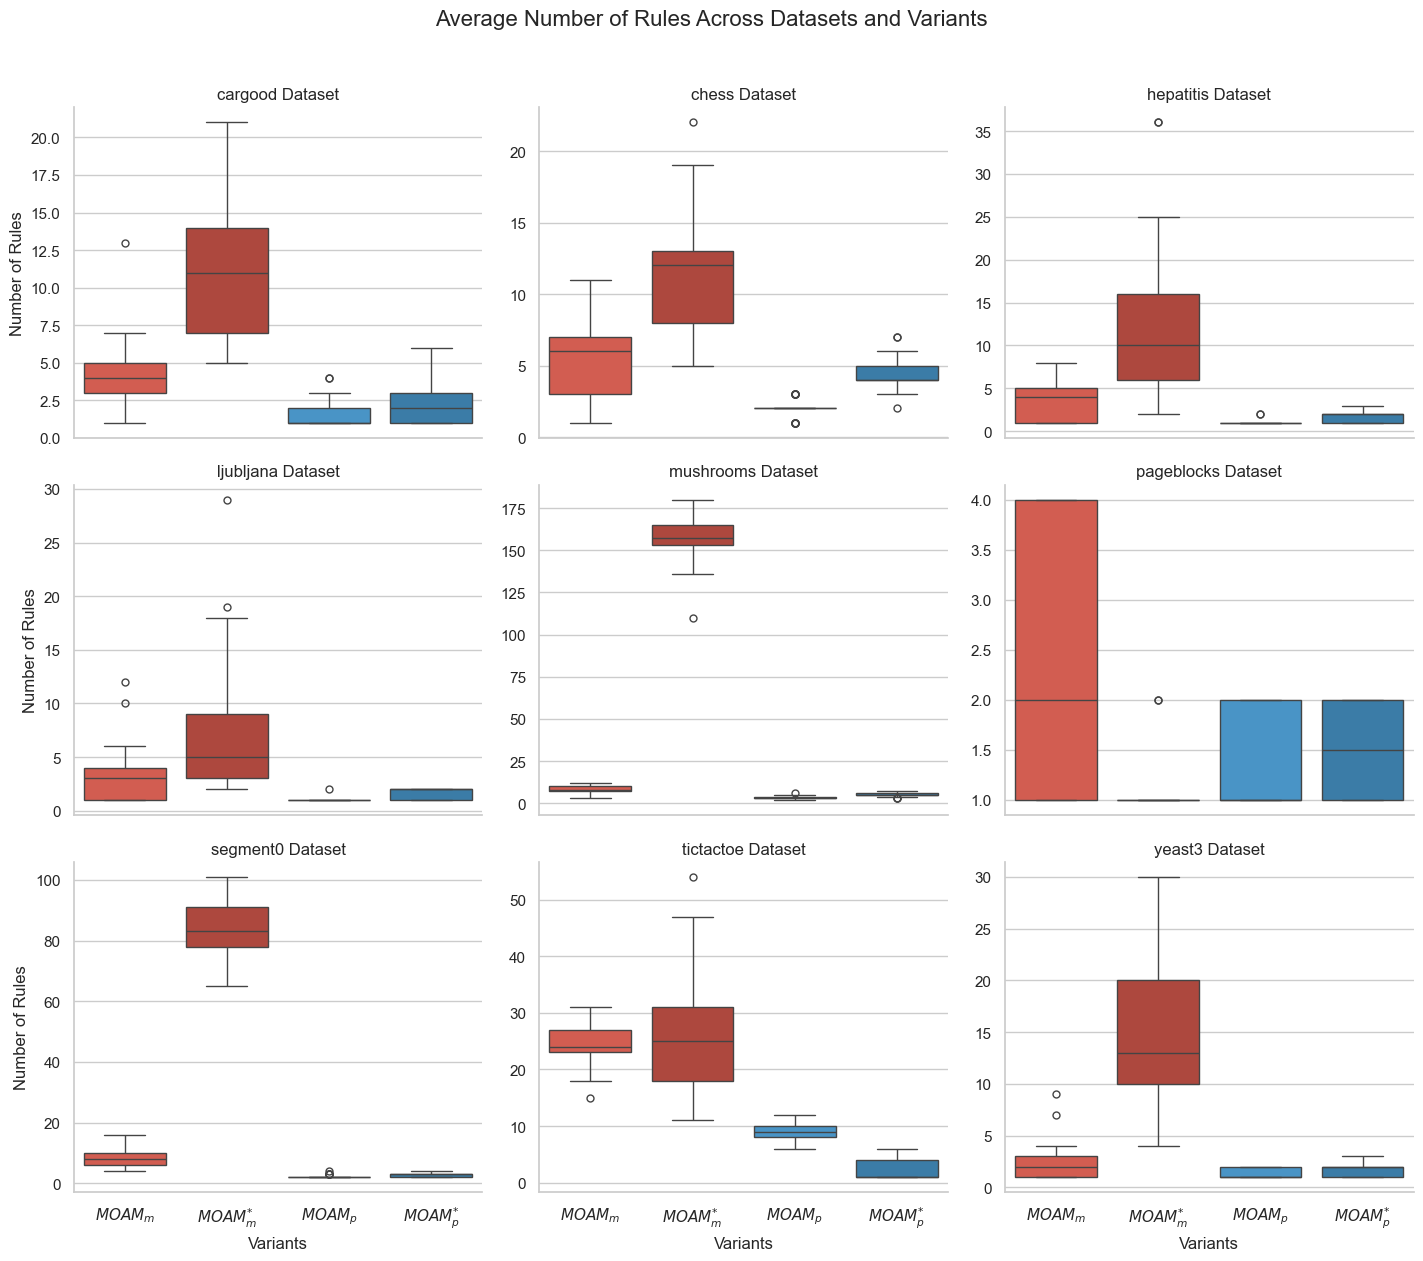

In [30]:
rule_counts = df_master.replace({"Variant": LABEL_MAP}).groupby(['Dataset', 'Variant', 'Run', 'Fold']).size().reset_index(name='Total_Rules')

g = sns.catplot(
    data=rule_counts, 
    x='Variant', 
    y='Total_Rules', 
    col='Dataset', 
    col_wrap=3,
    kind='box', 
    palette=['#e74c3c', '#c0392b', '#3498db', '#2980b9'],
    hue='Variant',
    height=4, 
    aspect=1.2,
    sharey=False
)

g.set_titles("{col_name} Dataset")
g.set_axis_labels("Variants", "Number of Rules")
plt.suptitle('Average Number of Rules Across Datasets and Variants', y=1.05, fontsize=16)
plt.show()

### Rule Length

In [31]:
avg_rule_lengths = df_master.replace({"Variant": LABEL_MAP}).groupby(['Variant']).agg({'Rule_Length': 'mean'}).reset_index()
avg_rule_lengths

,Variant,Rule_Length
0,$MOAM_{m}$,1.827225
1,$MOAM_{m}^{*}$,1.307996
2,$MOAM_{p}$,1.790861
3,$MOAM_{p}^{*}$,1.891608


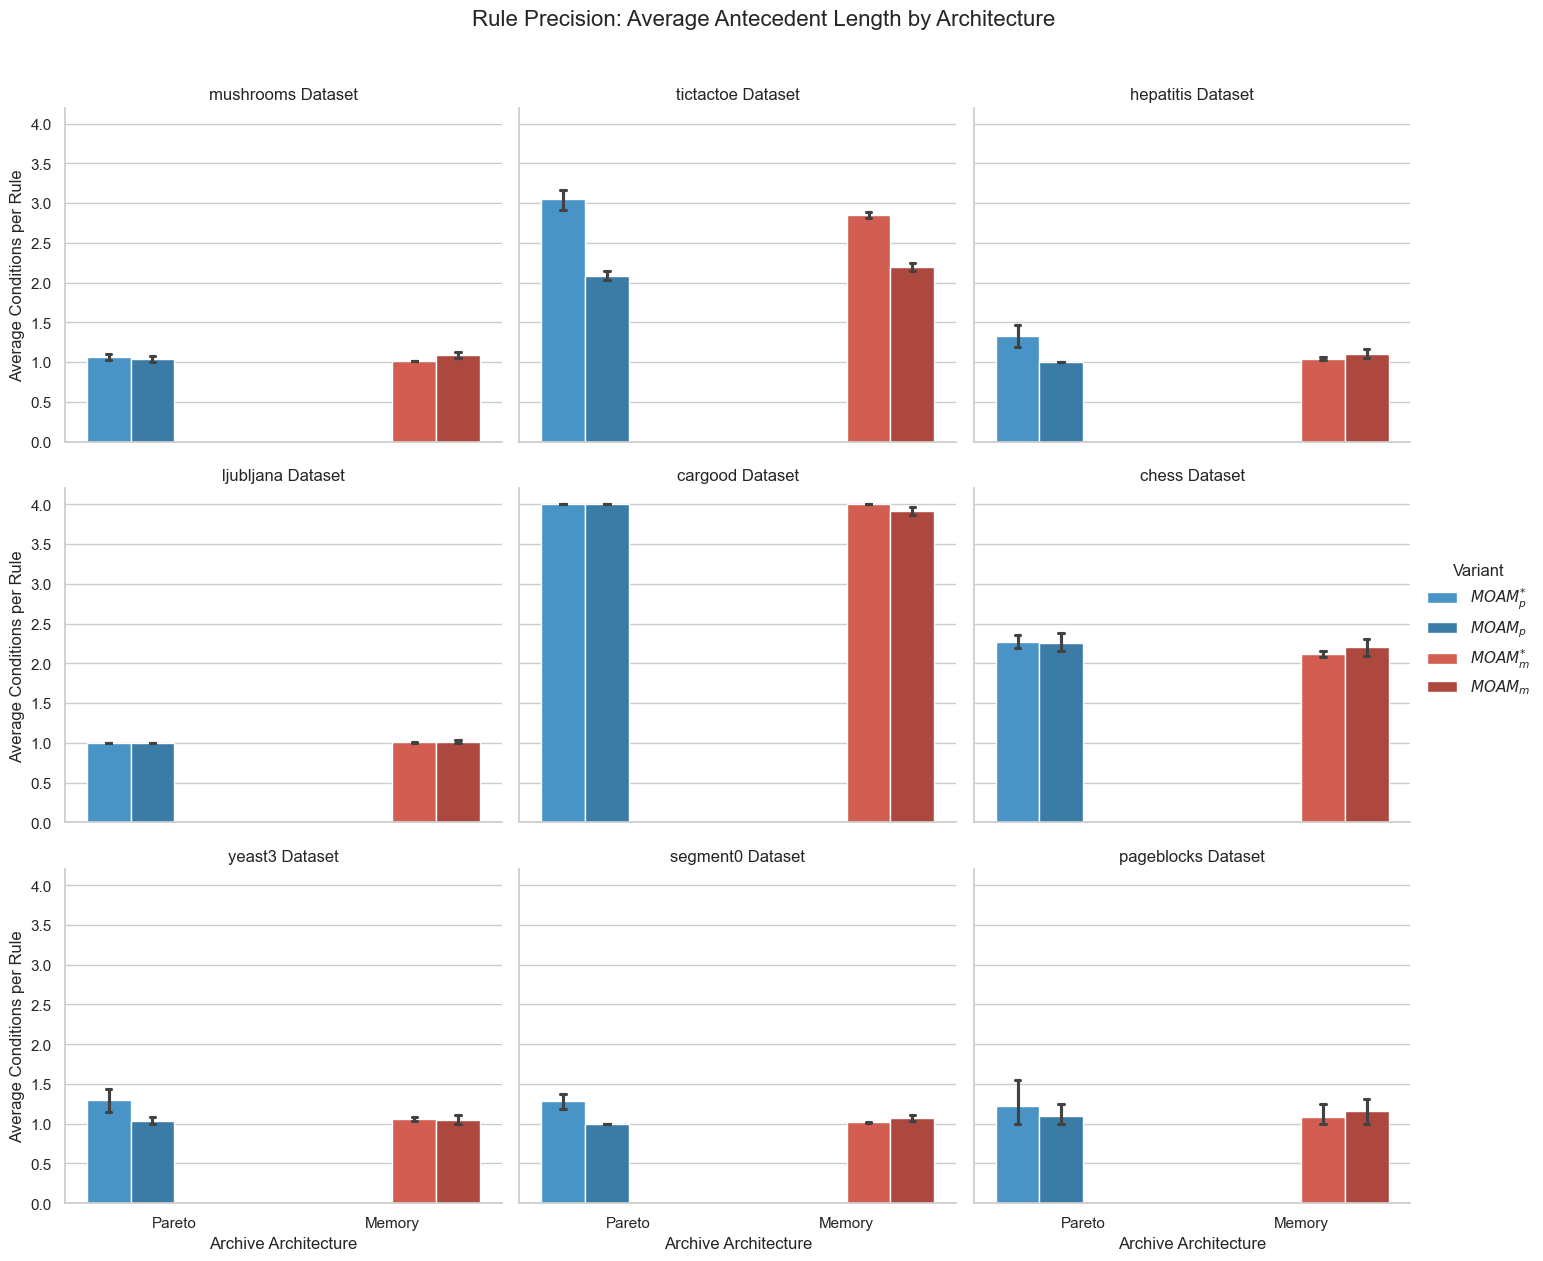

In [32]:
g = sns.catplot(
    data=df_master.replace({"Variant": LABEL_MAP}), 
    x='Archive_Type', 
    y='Rule_Length', 
    hue='Variant',
    col='Dataset', 
    col_wrap=3,
    kind='bar',
    capsize=0.1, 
    palette=['#3498db', '#2980b9', '#e74c3c', '#c0392b'],
    height=4, 
    aspect=1.2
)
g.set_titles("{col_name} Dataset")
g.set_axis_labels("Archive Architecture", "Average Conditions per Rule")
plt.suptitle('Rule Precision: Average Antecedent Length by Architecture', y=1.05, fontsize=16)
plt.show()

### Objective Space

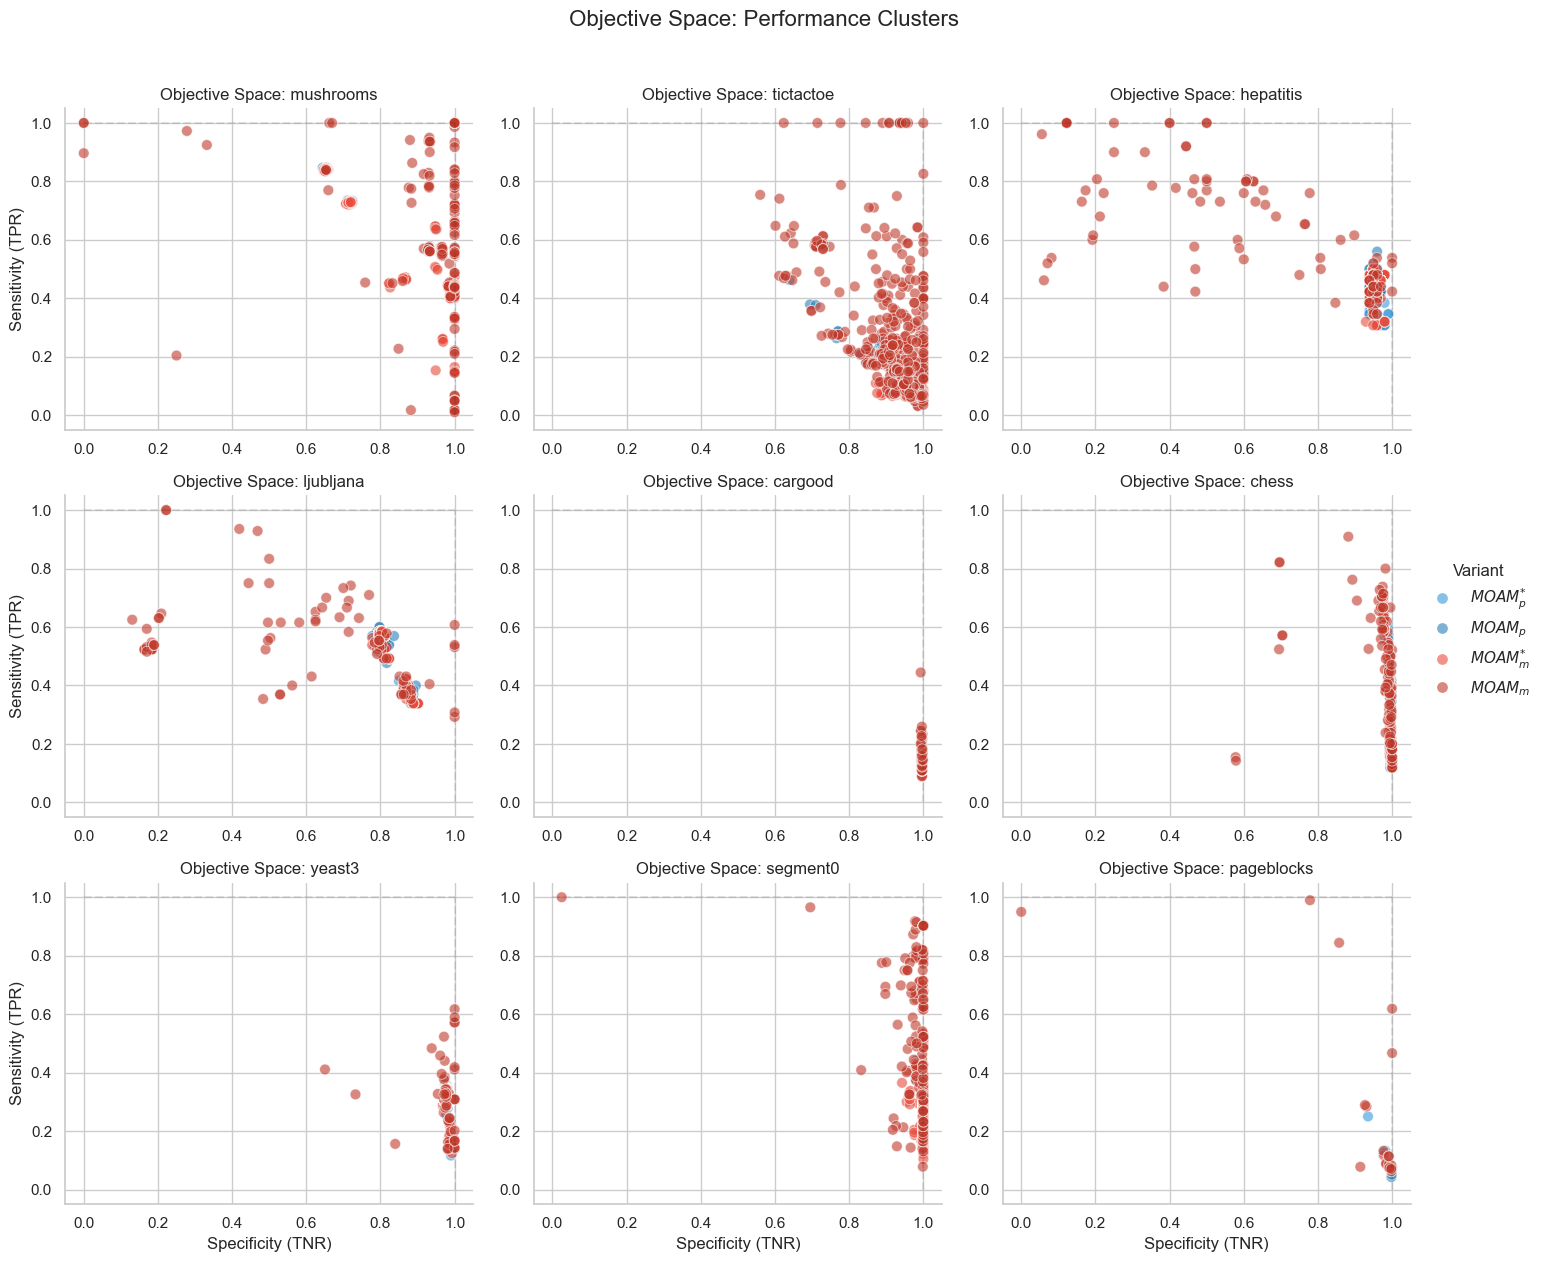

In [39]:
g = sns.relplot(
    data= df_master.replace({"Variant": LABEL_MAP}),
    x='Specificity',
    y='Sensitivity',
    hue='Variant',
    col='Dataset',
    col_wrap=3,
    alpha=0.6,
    s=60,
    palette=['#3498db', '#2980b9', '#e74c3c', '#c0392b'],
    height=4,
    aspect=1.2,
    facet_kws={'sharex': False, 'sharey': False} # Let the axes adapt to each dataset's cluster
)

g.set_titles("Objective Space: {col_name}")
g.set_axis_labels("Specificity (TNR)", "Sensitivity (TPR)")

for ax in g.axes.flat:
    ax.plot([0, 1], [1, 1], 'k--', alpha=0.1)
    ax.plot([1, 1], [0, 1], 'k--', alpha=0.1)

plt.suptitle('Objective Space: Performance Clusters', y=1.05, fontsize=16)
plt.show()

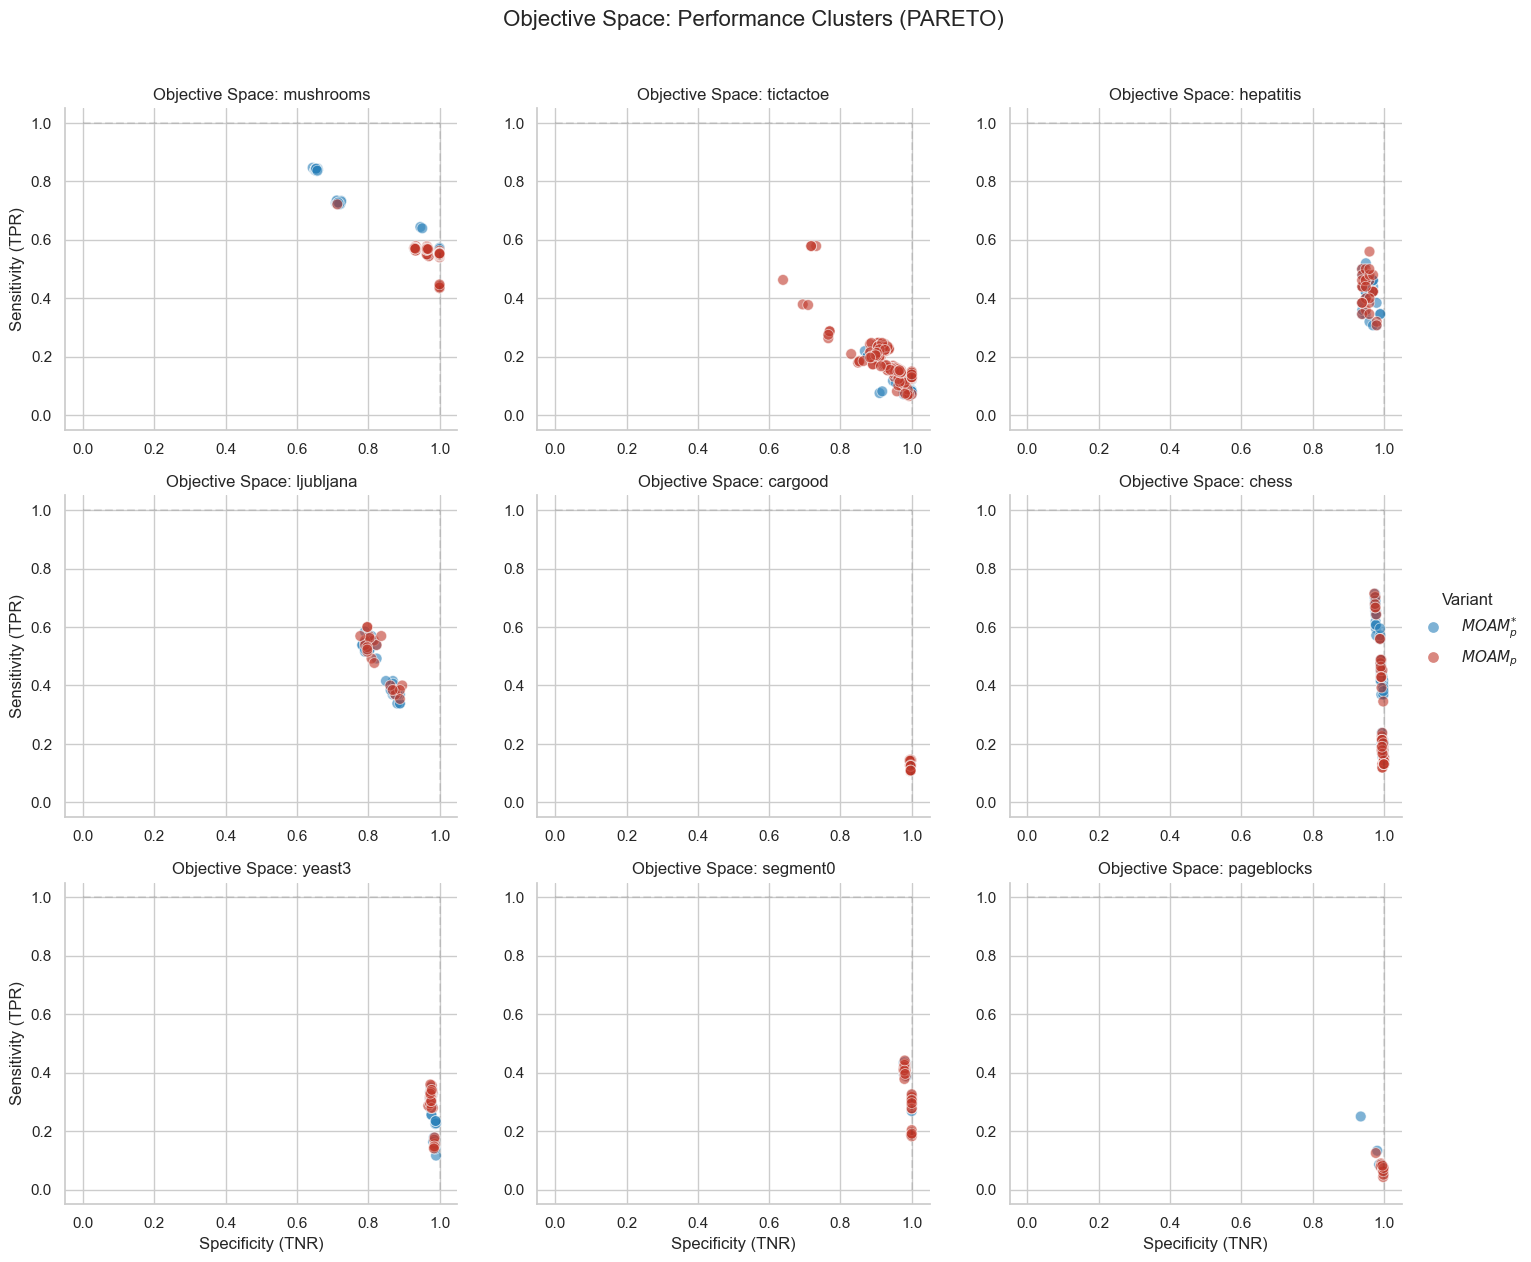

In [42]:
variants = ["MOEAAM2", "MOEAAM2_DC"]
new_data = df_master[df_master['Variant'].isin(variants)].replace({"Variant": LABEL_MAP})

g = sns.relplot(
    data= new_data,
    x='Specificity',
    y='Sensitivity',
    hue='Variant',
    col='Dataset',
    col_wrap=3,
    alpha=0.6,
    s=60,
    palette=['#2980b9', '#c0392b'],
    height=4,
    aspect=1.2,
    facet_kws={'sharex': False, 'sharey': False} # Let the axes adapt to each dataset's cluster
)

g.set_titles("Objective Space: {col_name}")
g.set_axis_labels("Specificity (TNR)", "Sensitivity (TPR)")

for ax in g.axes.flat:
    ax.plot([0, 1], [1, 1], 'k--', alpha=0.1)
    ax.plot([1, 1], [0, 1], 'k--', alpha=0.1)

plt.suptitle('Objective Space: Performance Clusters (PARETO)', y=1.05, fontsize=16)
plt.show()

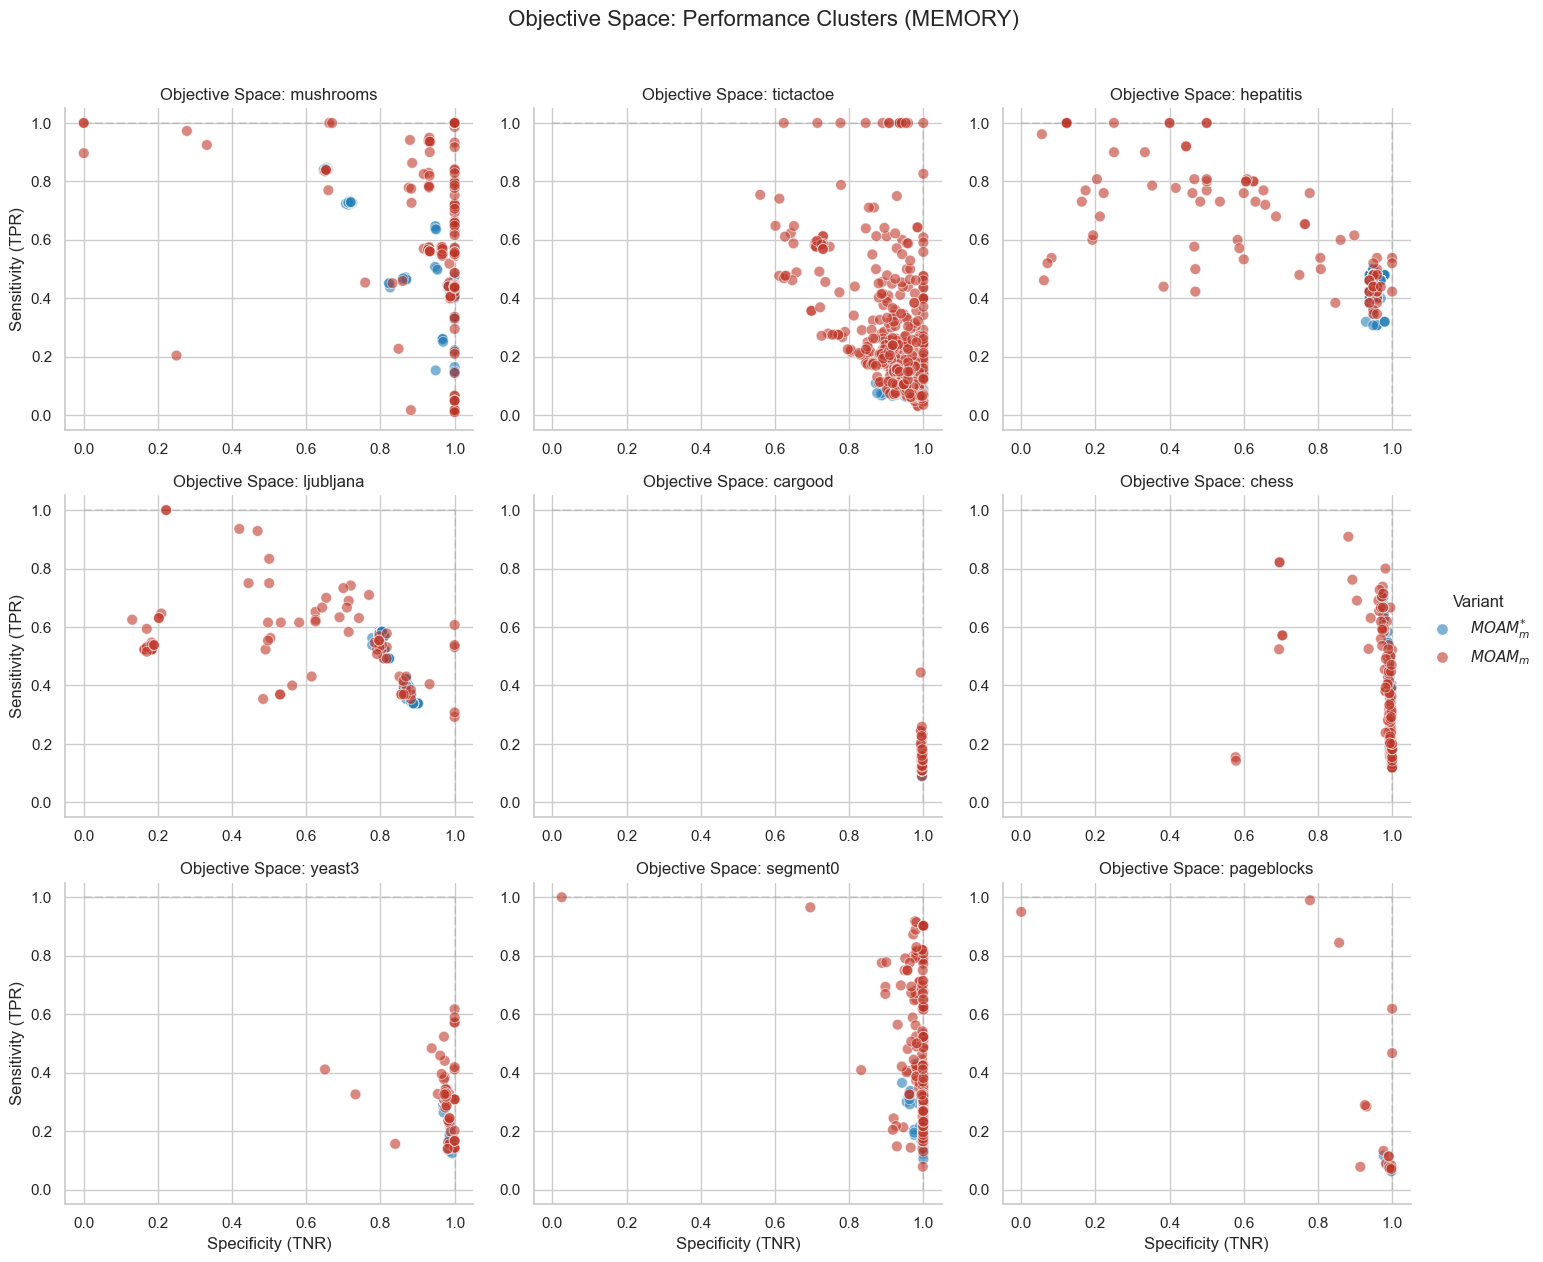

In [43]:
variants = ["MOEAAM2_IRS", "MOEAAM2_IRS_DC"]
new_data = df_master[df_master['Variant'].isin(variants)].replace({"Variant": LABEL_MAP})

g = sns.relplot(
    data= new_data,
    x='Specificity',
    y='Sensitivity',
    hue='Variant',
    col='Dataset',
    col_wrap=3,
    alpha=0.6,
    s=60,
    palette=['#2980b9', '#c0392b'],
    height=4,
    aspect=1.2,
    facet_kws={'sharex': False, 'sharey': False} # Let the axes adapt to each dataset's cluster
)

g.set_titles("Objective Space: {col_name}")
g.set_axis_labels("Specificity (TNR)", "Sensitivity (TPR)")

for ax in g.axes.flat:
    ax.plot([0, 1], [1, 1], 'k--', alpha=0.1)
    ax.plot([1, 1], [0, 1], 'k--', alpha=0.1)

plt.suptitle('Objective Space: Performance Clusters (MEMORY)', y=1.05, fontsize=16)
plt.show()

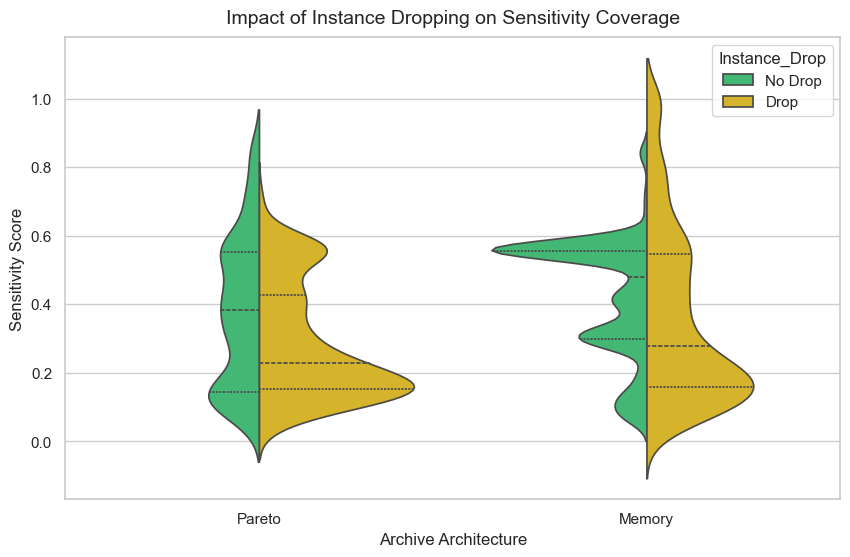

In [35]:
# Focus specifically on how dropping affects Sensitivity
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_master.replace({"Variant": LABEL_MAP}), 
    x='Archive_Type', 
    y='Sensitivity', 
    hue='Instance_Drop', 
    split=True, 
    inner='quartile',
    palette=['#2ecc71', '#f1c40f']
)
plt.title('Impact of Instance Dropping on Sensitivity Coverage', fontsize=14, pad=10)
plt.ylabel('Sensitivity Score', fontsize=12)
plt.xlabel('Archive Architecture', fontsize=12)
plt.show()

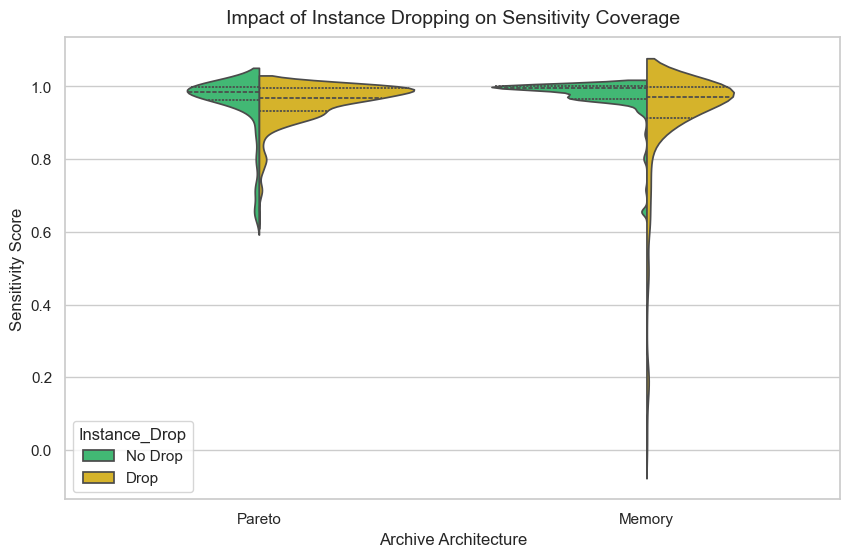

In [36]:
# Focus specifically on how dropping affects Sensitivity
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df_master.replace({"Variant": LABEL_MAP}), 
    x='Archive_Type', 
    y='Specificity', 
    hue='Instance_Drop', 
    split=True, 
    inner='quartile',
    palette=['#2ecc71', '#f1c40f']
)
plt.title('Impact of Instance Dropping on Sensitivity Coverage', fontsize=14, pad=10)
plt.ylabel('Sensitivity Score', fontsize=12)
plt.xlabel('Archive Architecture', fontsize=12)
plt.show()